# Лабораторная работа 6

In [2]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from lab6_pipeline import (
    CLASS_NAMES,
    auto_device,
    dataset_summary,
    download_rtsd_segmentation_dataset,
    evaluate_custom_images,
    evaluate_rtsd_validation,
    export_custom_predictions,
    plot_iou_thresholds,
    plot_training_curves,
    prepare_yolo_dataset,
    preview_ground_truth,
    save_prediction_overlays,
    train_segmentation_model,
)

DATA_DIR = PROJECT_ROOT / 'data'
YOLO_DATASET_DIR = DATA_DIR / 'yolo_dataset'
RUNS_DIR = PROJECT_ROOT / 'runs'
REPORTS_DIR = PROJECT_ROOT / 'reports'
CUSTOM_IMAGES_DIR = DATA_DIR / 'custom' / 'images'
CUSTOM_MASKS_DIR = DATA_DIR / 'custom' / 'masks'

for path in [DATA_DIR, YOLO_DATASET_DIR, RUNS_DIR, REPORTS_DIR, CUSTOM_IMAGES_DIR, CUSTOM_MASKS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Device:', auto_device())
print('Classes:', CLASS_NAMES)

Project root: /Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt
Device: cpu
Classes: ['class_1', 'class_2', 'class_3', 'class_4', 'class_6', 'class_8', 'class_10', 'class_13']


## 1. Подготовка датасета

Исходный датасет скачивается через `kagglehub`, после чего переводится в формат `YOLO Segmentation`.

In [3]:
RAW_ROOT = download_rtsd_segmentation_dataset()
prepared = prepare_yolo_dataset(
    raw_root=RAW_ROOT,
    output_root=YOLO_DATASET_DIR,
    overwrite=True,
)

print('Raw dataset:', prepared.raw_root)
print('YOLO dataset:', prepared.yolo_root)
print('dataset.yaml:', prepared.data_yaml)

100%|██████████| 401M/401M [00:45<00:00, 9.32MB/s] 

Extracting files...


Raw dataset: /Users/maxim-bovt/.cache/kagglehub/datasets/viacheslavshalamov/russian-road-signs-segmentation-dataset/versions/1/sign_dataset
YOLO dataset: /Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/data/yolo_dataset
dataset.yaml: /Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/data/yolo_dataset/dataset.yaml


,split,images,instances,class_1,class_2,class_3,class_4,class_6,class_8,class_10,class_13
0,train,2054,13489,1378,19,9933,14,111,1435,597,2
1,val,127,739,84,0,531,0,9,86,28,1


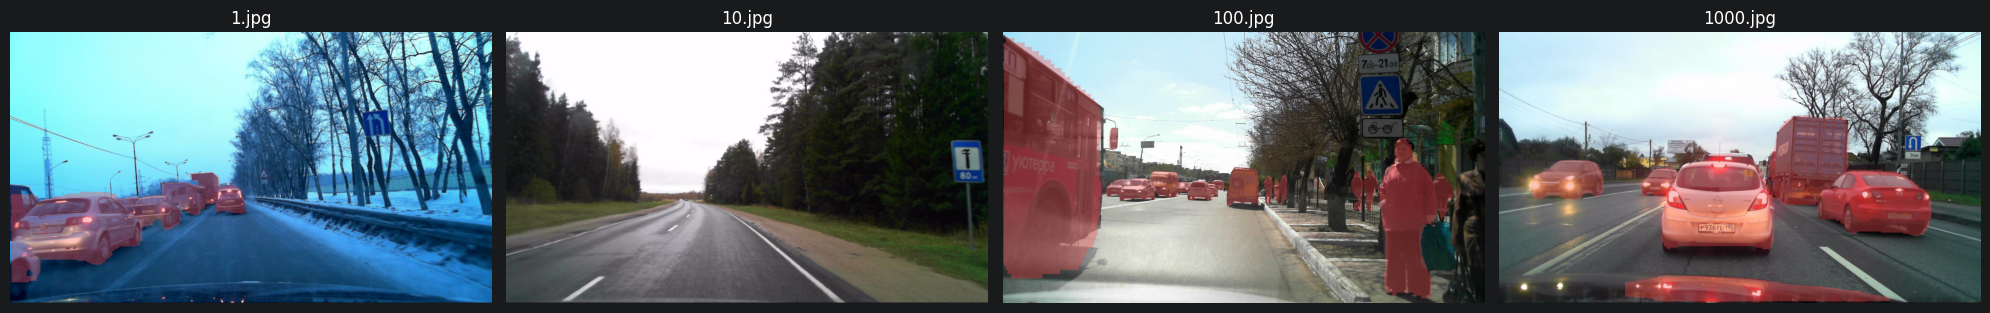

In [4]:
summary_df = dataset_summary(prepared.raw_root)
display(summary_df)
preview_ground_truth(prepared.raw_root, split='train', limit=4)

## 2. Обучение модели

Для простоты используется легкая предобученная модель `YOLO11n-seg`.

Если обучение уже запускалось и веса есть, эту ячейку можно пропустить.

In [8]:
MODEL_NAME = 'yolo11n-seg.pt'
EPOCHS = 1
IMGSZ = 640
BATCH = 8
RUN_NAME = 'road_signs_seg'

run_dir = train_segmentation_model(
    data_yaml=prepared.data_yaml,
    output_root=RUNS_DIR,
    model_name=MODEL_NAME,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    run_name=RUN_NAME,
)

BEST_MODEL_PATH = run_dir / 'weights' / 'best.pt'
print('Run dir:', run_dir)
print('Best model:', BEST_MODEL_PATH)

New https://pypi.org/project/ultralytics/8.4.129 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.36 🚀 Python-3.12.14 torch-2.13.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/data/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.

In [9]:
training_curves_path = plot_training_curves(run_dir, REPORTS_DIR / 'training_curves.png')
print('Training curves saved to:', training_curves_path)

Training curves saved to: /Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/training_curves.png


## 3. Оценка на валидации датасета

In [10]:
validation_metrics_df, validation_summary_df = evaluate_rtsd_validation(
    model_source=BEST_MODEL_PATH,
    raw_root=prepared.raw_root,
    output_dir=REPORTS_DIR / 'validation',
    imgsz=IMGSZ,
    conf=0.25,
)

display(validation_metrics_df.head())
display(validation_summary_df)

plot_iou_thresholds(
    validation_summary_df,
    title='Validation IoU Thresholds',
    save_path=REPORTS_DIR / 'validation' / 'validation_iou_thresholds.png',
)

save_prediction_overlays(
    model_source=BEST_MODEL_PATH,
    image_paths=sorted((prepared.raw_root / 'val').glob('*.jpg'))[:10],
    output_dir=REPORTS_DIR / 'validation' / 'overlays',
    imgsz=IMGSZ,
    conf=0.25,
)

,iou,precision,recall,l2,image_name
0,0.558390,0.795632,0.651890,0.127985,201.jpg
1,0.000000,0.000000,0.000000,0.024760,202.jpg
2,0.000000,0.000000,0.000000,0.077308,203.jpg
3,0.000000,0.000000,0.000000,0.074412,204.jpg
4,0.733438,0.884493,0.811128,0.098833,205.jpg


,images,mean_iou,mean_precision,mean_recall,mean_l2,share_iou_ge_0_5,share_iou_ge_0_75,share_iou_ge_0_9
0,127,0.546406,0.55808,0.599532,0.104589,0.637795,0.354331,0.110236


[PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/201.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/202.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/203.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/204.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/205.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/206.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/207.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/208.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects/CV/ITMO-cv-labs-bovt/reports/validation/overlays/2083.jpg'),
 PosixPath('/Users/maxim-bovt/PycharmProjects

## 4. Оценка на своих 10 фотографиях

In [11]:
custom_image_files = sorted(
    [
        path
        for path in CUSTOM_IMAGES_DIR.glob("*")
        if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
    ]
)
custom_report_dir = REPORTS_DIR / "custom"

if len(custom_image_files) == 0:
    print("В папке data/custom/images пока нет фотографий.")
else:
    predictions_df = export_custom_predictions(
        model_source=BEST_MODEL_PATH,
        images_dir=CUSTOM_IMAGES_DIR,
        output_dir=custom_report_dir,
        imgsz=IMGSZ,
        conf=0.25,
    )
    display(predictions_df)

    available_mask_files = {
        path.stem
        for path in CUSTOM_MASKS_DIR.glob("*")
        if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
    }
    all_masks_exist = all(path.stem in available_mask_files for path in custom_image_files)

    if all_masks_exist:
        custom_metrics_df, custom_summary_df = evaluate_custom_images(
            model_source=BEST_MODEL_PATH,
            images_dir=CUSTOM_IMAGES_DIR,
            masks_dir=CUSTOM_MASKS_DIR,
            output_dir=custom_report_dir,
            imgsz=IMGSZ,
            conf=0.25,
        )
        display(custom_metrics_df)
        display(custom_summary_df)
        plot_iou_thresholds(
            custom_summary_df,
            title="Custom Photos IoU Thresholds",
            save_path=custom_report_dir / "custom_iou_thresholds.png",
        )
        print("Метрики посчитаны и сохранены в:", custom_report_dir)
    else:
        print("Истинных бинарных масок нет или их не хватает. Поэтому сохранены только предсказания.")
        print("Predicted masks:", custom_report_dir / "predicted_masks")
        print("Overlays:", custom_report_dir / "overlays")


В папке data/custom/images пока нет фотографий.
